In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torchtext.data import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import nltk
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import re
import string




In [8]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [46]:
class TweetCleaner:
    def __init__(self, filepath, encoding='latin1'):
        self.df = pd.read_csv(filepath, encoding=encoding)
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

    def preprocess_text(self, text):
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#\w+', '', text)
        text = re.sub(r'http\S+', '', text)
        text = re.sub(r'\d+', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F1E0-\U0001F1FF"
            u"\U00002700-\U000027BF"
            u"\U000024C2-\U0001F251"
            "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)
        text = text.lower()
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def remove_stopwords(self, text):
        return ' '.join([word for word in text.split() if word not in self.stop_words])

    def lemmatize_text(self, text):
        return ' '.join([self.lemmatizer.lemmatize(word) for word in text.split()])
    def is_english(self, text):
        try:
            return detect(text) == 'en'
        except LangDetectException:
            return False
    def handle_missing_values(self):
        self.df = self.df.dropna(subset=['tweet_text'])
        self.df['emotion_in_tweet_is_directed_at'] = self.df['emotion_in_tweet_is_directed_at'].fillna('Unknown')
        return self.df
    def full_text_processing(self):
        
        # Handle missing values and duplicates
        self.df = self.df.dropna(subset=['tweet_text'])
        self.df = self.df.drop_duplicates(subset=['tweet_text'])
        
        # Filter English text
        self.df = self.df[self.df['tweet_text'].apply(self.is_english)]
        
        # Remove garbled text
        self.df = self.df[~self.df['tweet_text'].str.contains('�')]
        self.df['processed_text'] = self.df['tweet_text'].astype(str).apply(self.preprocess_text)
        self.df['processed_text'] = self.df['processed_text'].apply(self.remove_stopwords)
        self.df['processed_text'] = self.df['processed_text'].apply(self.lemmatize_text)
        self.df['emotion_in_tweet_is_directed_at'] = self.df['emotion_in_tweet_is_directed_at'].fillna('Unknown')
        return self.df


In [47]:
cleaner = TweetCleaner('judge-1377884607_tweet_product_company.csv', encoding='latin1')
cleaner.full_text_processing()
cleaner.handle_missing_values()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,processed_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,g iphone hr tweeting dead need upgrade plugin ...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,wait also sale
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,hope year festival isnt crashy year iphone app
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri marissa mayer google tim oreil...
...,...,...,...,...
9087,"@mention Yup, but I don't have a third app yet...",Unknown,No emotion toward brand or product,yup dont third app yet im android suggestion cc
9088,Ipad everywhere. #SXSW {link},iPad,Positive emotion,ipad everywhere link
9089,"Wave, buzz... RT @mention We interrupt your re...",Unknown,No emotion toward brand or product,wave buzz rt interrupt regularly scheduled gee...
9090,"Google's Zeiger, a physician never reported po...",Unknown,No emotion toward brand or product,google zeiger physician never reported potenti...


In [48]:
cleaner.df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8992 entries, 0 to 9091
Data columns (total 4 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          8992 non-null   object
 1   emotion_in_tweet_is_directed_at                     8992 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  8992 non-null   object
 3   processed_text                                      8992 non-null   object
dtypes: object(4)
memory usage: 351.2+ KB


In [49]:
cleaner.df.describe()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,processed_text
count,8992,8992,8992,8992
unique,8992,10,4,8553
top,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,Unknown,No emotion toward brand or product,rt google launch major new social network call...
freq,1,5732,5320,21


In [50]:
cleaner.df.shape

(8992, 4)

In [51]:
# Remove duplicates
cleaner.df = cleaner.df.drop_duplicates(subset=['tweet_text'])
cleaner.df = cleaner.df[~cleaner.df['processed_text'].str.contains('�')]

In [52]:
cleaner.df.isnull().sum()

tweet_text                                            0
emotion_in_tweet_is_directed_at                       0
is_there_an_emotion_directed_at_a_brand_or_product    0
processed_text                                        0
dtype: int64

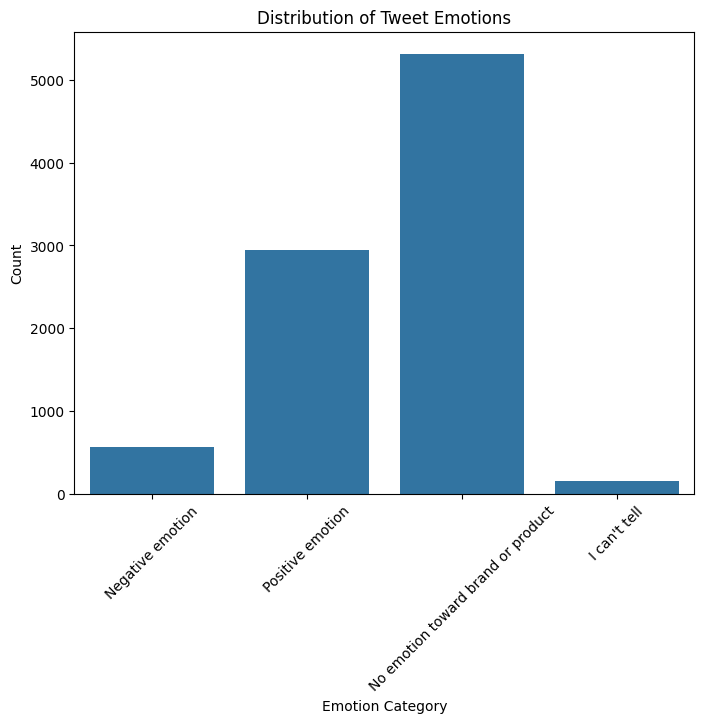

In [53]:
# Class Distribution Plot
plt.figure(figsize=(8, 6))
sns.countplot(data=cleaner.df, x='is_there_an_emotion_directed_at_a_brand_or_product')
plt.title('Distribution of Tweet Emotions')
plt.xlabel('Emotion Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


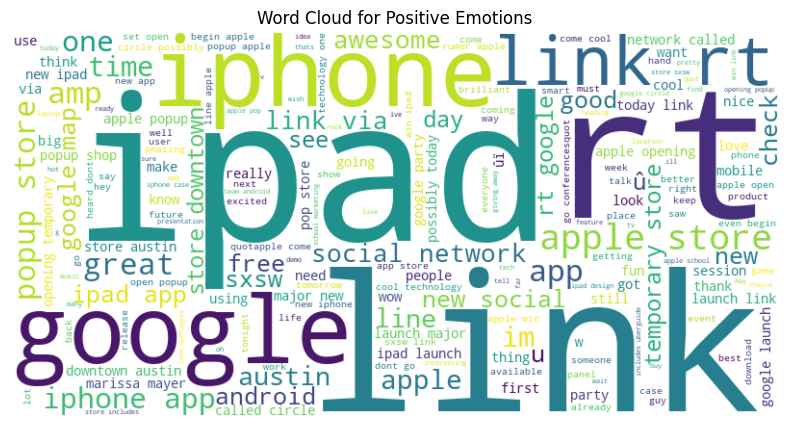

In [54]:
# Word Cloud for Positive Emotions
from wordcloud import WordCloud

positive_tweets = cleaner.df[cleaner.df['is_there_an_emotion_directed_at_a_brand_or_product'] == 'Positive emotion']['processed_text']
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(positive_tweets))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Emotions')
plt.show()

In [55]:
# Encode target variable
le = LabelEncoder()
cleaner.df['emotion_encoded'] = le.fit_transform(cleaner.df['is_there_an_emotion_directed_at_a_brand_or_product'])
cleaner.df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,processed_text,emotion_encoded
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,g iphone hr tweeting dead need upgrade plugin ...,1
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,know awesome ipadiphone app youll likely appre...,3
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,wait also sale,3
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,hope year festival isnt crashy year iphone app,1
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri marissa mayer google tim oreil...,3


In [56]:
# Prepare features and target
X = cleaner.df['processed_text']
y = cleaner.df['emotion_encoded']

In [57]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [58]:
# Compute class weights to handle imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))


In [59]:
class TextClassifierTrainer:
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test

        self.models = {
            'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear'),
            'Decision Tree': DecisionTreeClassifier(),
            'Random Forest': RandomForestClassifier(),
            'SVM': SVC(probability=True),
            'Linear SVC': LinearSVC(),
            'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
        }

        self.param_grids = self.get_param_grids()
        self.best_models = {}
    

In [60]:
class HyperparameterGrids:
    def get_param_grids(self):
        return {
            'Logistic Regression': {
                'tfidf__max_features': [3000, 5000],
                'clf__C': [0.1, 1, 10],
                'clf__penalty': ['l1', 'l2'],
                'clf__solver': ['liblinear']
            },
            'Decision Tree': {
                'tfidf__max_features': [3000, 5000],
                'clf__max_depth': [None, 10, 20],
                'clf__min_samples_split': [2, 5]
            },
            'Random Forest': {
                'tfidf__max_features': [3000, 5000],
                'clf__n_estimators': [100, 200],
                'clf__max_depth': [None, 10]
            },
            'SVM': {
                'tfidf__max_features': [3000, 5000],
                'clf__C': [0.1, 1, 10],
                'clf__kernel': ['linear', 'rbf']
            },
            'Linear SVC': {
                'tfidf__max_features': [3000, 5000],
                'clf__C': [0.1, 1, 10]
            },
            'XGBoost': {
                'tfidf__max_features': [3000, 5000],
                'clf__n_estimators': [100, 200],
                'clf__learning_rate': [0.01, 0.1]
            }
        }


In [61]:
class ModelTrainer:
    def __init__(self, models, param_grids, X_train, y_train, cv=3, scoring='f1_weighted'):
        self.models = models
        self.param_grids = param_grids
        self.X_train = X_train
        self.y_train = y_train
        self.cv = cv
        self.scoring = scoring
        self.best_models = {}

    def train_all(self):
        for name, model in self.models.items():
            print(f"\nTraining {name}...")

            pipeline = Pipeline([
                ('tfidf', TfidfVectorizer()),
                ('clf', model)
            ])

            grid = GridSearchCV(pipeline, self.param_grids[name], cv=self.cv,
                                scoring=self.scoring, n_jobs=-1)
            grid.fit(self.X_train, self.y_train)

            print(f"Best score for {name}: {grid.best_score_:.4f}")
            print(f"Best params for {name}: {grid.best_params_}")

            self.best_models[name] = grid.best_estimator_

        return self.best_models


In [62]:
class ModelEvaluator:
    def __init__(self, best_models, X_test, y_test):
        self.best_models = best_models
        self.X_test = X_test
        self.y_test = y_test

    def evaluate(self, model_name):
        model = self.best_models.get(model_name)
        if model is None:
            print(f"Model '{model_name}' not found. Train models first.")
            return

        print(f"\nEvaluating {model_name} on test data:")
        y_pred = model.predict(self.X_test)

        print(f"Accuracy: {accuracy_score(self.y_test, y_pred):.4f}")
        print(f"F1 Score (weighted): {f1_score(self.y_test, y_pred, average='weighted'):.4f}")
        print("\nClassification Report:")
        print(classification_report(self.y_test, y_pred))

    def evaluate_all(self):
        for model_name in self.best_models.keys():
            self.evaluate(model_name)
